### Initializing

In [2]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression

pd.options.mode.copy_on_write = True

C:\Users\cdrSp\AppData\Local\Temp\ipykernel_2564\3683796857.py:9: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


In [3]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

### Setting up data

In [4]:
water_pollution = pd.read_csv('../final_project/water_pollution_disease.csv')
water_pollution

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,Mexico,North,2015,Lake,6.06,7.12,3.93,4.28,8.28,7.89,...,33,44,76.16,57057,96.92,84.61,63.23,2800,4.94,593
1,Brazil,West,2017,Well,5.24,7.84,4.79,3.86,15.74,14.68,...,27,8,77.30,17220,84.73,73.37,29.12,1572,16.93,234
2,Indonesia,Central,2022,Pond,0.24,6.43,0.79,3.42,36.67,9.96,...,39,50,48.45,86022,58.37,72.86,93.56,2074,21.73,57
3,Nigeria,East,2016,Well,7.91,6.71,1.96,3.12,36.92,6.77,...,33,13,95.66,31166,39.07,71.07,94.25,937,3.79,555
4,Mexico,South,2005,Well,0.12,8.16,4.22,9.15,49.35,12.51,...,31,68,58.78,25661,23.03,55.55,69.23,2295,31.44,414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Nigeria,East,2002,Tap,2.82,7.40,4.43,9.69,37.58,18.52,...,28,56,73.77,21255,75.34,15.22,53.06,264,31.64,882
2996,Nigeria,North,2019,Lake,8.13,8.33,4.77,7.62,38.05,16.98,...,34,34,71.11,79148,6.91,22.89,78.45,2699,33.21,67
2997,USA,South,2009,Pond,1.18,6.76,4.75,7.07,36.13,7.99,...,49,9,96.63,48569,86.17,85.89,47.38,1052,11.57,643
2998,Pakistan,South,2009,Pond,7.56,6.12,3.49,8.93,25.30,19.86,...,33,90,20.71,49099,20.50,20.78,23.34,369,14.69,643


In [5]:
variables = water_pollution[["Country","Region","Year","Water Source Type","Contaminant Level (ppm)","pH Level","Turbidity (NTU)","Dissolved Oxygen (mg/L)","Nitrate Level (mg/L)","Lead Concentration (µg/L)","Bacteria Count (CFU/mL)","Water Treatment Method","Access to Clean Water (% of Population)","Infant Mortality Rate (per 1,000 live births)","GDP per Capita (USD)","Healthcare Access Index (0-100)","Urbanization Rate (%)","Sanitation Coverage (% of Population)","Rainfall (mm per year)","Temperature (°C)","Population Density (people per km²)", "Diarrheal Cases per 100,000 people"]]

df = pd.DataFrame(variables)

# Dummify categorical variables
df_encoded = pd.get_dummies(df, columns=["Country", "Region", "Water Source Type", "Water Treatment Method"], drop_first=True, dtype=float)

print("Encoded DataFrame:")
print(df_encoded)

# X = pd.get_dummies(X, drop_first=True)
# X = sm.add_constant(X)

# df = pd.concat([X, Y], axis=1)

Encoded DataFrame:
      Year  Contaminant Level (ppm)  pH Level  Turbidity (NTU)  \
0     2015                     6.06      7.12             3.93   
1     2017                     5.24      7.84             4.79   
2     2022                     0.24      6.43             0.79   
3     2016                     7.91      6.71             1.96   
4     2005                     0.12      8.16             4.22   
...    ...                      ...       ...              ...   
2995  2002                     2.82      7.40             4.43   
2996  2019                     8.13      8.33             4.77   
2997  2009                     1.18      6.76             4.75   
2998  2009                     7.56      6.12             3.49   
2999  2013                     0.98      7.69             2.55   

      Dissolved Oxygen (mg/L)  Nitrate Level (mg/L)  \
0                        4.28                  8.28   
1                        3.86                 15.74   
2                      

In [6]:
X = df_encoded.drop("Diarrheal Cases per 100,000 people", axis=1)
y = df_encoded["Diarrheal Cases per 100,000 people"]

#Adding an intercept
X = sm.add_constant(X)

X

,const,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),...,Region_North,Region_South,Region_West,Water Source Type_Pond,Water Source Type_River,Water Source Type_Spring,Water Source Type_Tap,Water Source Type_Well,Water Treatment Method_Chlorination,Water Treatment Method_Filtration
0,1.0,2015,6.06,7.12,3.93,4.28,8.28,7.89,3344,33.60,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,2017,5.24,7.84,4.79,3.86,15.74,14.68,2122,89.54,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,2022,0.24,6.43,0.79,3.42,36.67,9.96,2330,35.29,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,2016,7.91,6.71,1.96,3.12,36.92,6.77,3779,57.53,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,2005,0.12,8.16,4.22,9.15,49.35,12.51,4182,36.60,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1.0,2002,2.82,7.40,4.43,9.69,37.58,18.52,359,36.34,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2996,1.0,2019,8.13,8.33,4.77,7.62,38.05,16.98,3810,81.72,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2997,1.0,2009,1.18,6.76,4.75,7.07,36.13,7.99,1440,80.11,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2998,1.0,2009,7.56,6.12,3.49,8.93,25.30,19.86,2919,78.26,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=314,
                                                    test_size=0.25,
                                                    shuffle=True) 
Train = pd.concat([X_train, y_train], axis=1)
Test = pd.concat([X_test, y_test], axis=1)

In [7]:
# Spot check the train and test sets

print(X_train.head()) 
print(X_train.shape)
print()
print(y_train.head()) 
print(y_train.shape)
print() 
print(X_test.head()) 
print(X_test.shape)
print() 
print(y_test.head())
print(y_test.shape)
print() 
print(Train.head())
print(Train.shape)
print() 
print(Test.head())
print(Test.shape)

      const  Year  Contaminant Level (ppm)  pH Level  Turbidity (NTU)  \
344     1.0  2020                     5.60      8.40             3.64   
1884    1.0  2004                     1.92      6.71             0.82   
1058    1.0  2002                     6.70      6.24             4.18   
807     1.0  2000                     5.84      6.75             0.97   
1218    1.0  2003                     9.10      7.98             3.13   

      Dissolved Oxygen (mg/L)  Nitrate Level (mg/L)  \
344                      5.86                 39.86   
1884                     5.02                 18.75   
1058                     6.14                 31.82   
807                      3.46                 21.41   
1218                     4.49                  8.95   

      Lead Concentration (µg/L)  Bacteria Count (CFU/mL)  \
344                       14.95                     2157   
1884                      16.34                     2517   
1058                       9.27                   

In [8]:
print(Train.columns)

Index(['const', 'Year', 'Contaminant Level (ppm)', 'pH Level',
       'Turbidity (NTU)', 'Dissolved Oxygen (mg/L)', 'Nitrate Level (mg/L)',
       'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)',
       'Access to Clean Water (% of Population)',
       'Infant Mortality Rate (per 1,000 live births)', 'GDP per Capita (USD)',
       'Healthcare Access Index (0-100)', 'Urbanization Rate (%)',
       'Sanitation Coverage (% of Population)', 'Rainfall (mm per year)',
       'Temperature (°C)', 'Population Density (people per km²)',
       'Country_Brazil', 'Country_China', 'Country_Ethiopia', 'Country_India',
       'Country_Indonesia', 'Country_Mexico', 'Country_Nigeria',
       'Country_Pakistan', 'Country_USA', 'Region_East', 'Region_North',
       'Region_South', 'Region_West', 'Water Source Type_Pond',
       'Water Source Type_River', 'Water Source Type_Spring',
       'Water Source Type_Tap', 'Water Source Type_Well',
       'Water Treatment Method_Chlorination',
       'Water

### Correlations

In [9]:
Train.select_dtypes(include='number').corr()

,const,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),...,Region_South,Region_West,Water Source Type_Pond,Water Source Type_River,Water Source Type_Spring,Water Source Type_Tap,Water Source Type_Well,Water Treatment Method_Chlorination,Water Treatment Method_Filtration,"Diarrheal Cases per 100,000 people"
const,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,NaN,1.000000,-0.013843,-0.007575,-0.000783,-0.013907,-0.008817,-0.013057,-0.015406,0.009262,...,0.014927,0.019213,-0.005175,-0.012142,-0.036222,-0.017748,0.040042,-0.019423,0.035508,-0.008256
Contaminant Level (ppm),NaN,-0.013843,1.000000,0.008666,0.035000,0.000106,-0.049234,0.041970,0.014303,-0.002727,...,0.012729,0.005763,-0.026690,0.002022,-0.003087,0.014561,0.020633,0.023846,-0.005761,0.000933
pH Level,NaN,-0.007575,0.008666,1.000000,-0.044096,-0.006642,0.001716,-0.000636,0.026676,0.032276,...,0.037052,0.026517,0.005703,0.006879,-0.017299,0.012852,-0.040999,0.011507,-0.035402,0.023742
Turbidity (NTU),NaN,-0.000783,0.035000,-0.044096,1.000000,-0.008444,0.017717,-0.011578,0.012436,0.024831,...,-0.025905,0.010408,0.006168,0.012962,-0.025199,-0.020923,0.019840,-0.006487,-0.022277,0.015123
Dissolved Oxygen (mg/L),NaN,-0.013907,0.000106,-0.006642,-0.008444,1.000000,-0.018309,0.016476,0.005610,0.010801,...,0.001097,0.001470,-0.024837,-0.028191,0.016541,-0.000363,0.031104,-0.013530,0.023699,-0.009251
Nitrate Level (mg/L),NaN,-0.008817,-0.049234,0.001716,0.017717,-0.018309,1.000000,0.004525,-0.018127,0.025238,...,0.019388,0.007089,-0.025974,0.011504,-0.012874,0.024240,0.018697,0.023238,-0.005248,-0.026836
Lead Concentration (µg/L),NaN,-0.013057,0.041970,-0.000636,-0.011578,0.016476,0.004525,1.000000,0.006349,0.004896,...,-0.008376,0.007475,0.013623,-0.009501,-0.016607,-0.012035,0.014227,-0.015360,0.026054,0.006181
Bacteria Count (CFU/mL),NaN,-0.015406,0.014303,0.026676,0.012436,0.005610,-0.018127,0.006349,1.000000,0.000663,...,0.020935,0.021731,-0.005390,-0.012458,0.020617,-0.011184,0.014615,-0.026964,-0.026237,0.025526
Access to Clean Water (% of Population),NaN,0.009262,-0.002727,0.032276,0.024831,0.010801,0.025238,0.004896,0.000663,1.000000,...,0.000879,0.016499,0.031838,-0.012881,0.010031,-0.013607,-0.013470,0.008132,-0.017868,0.003195


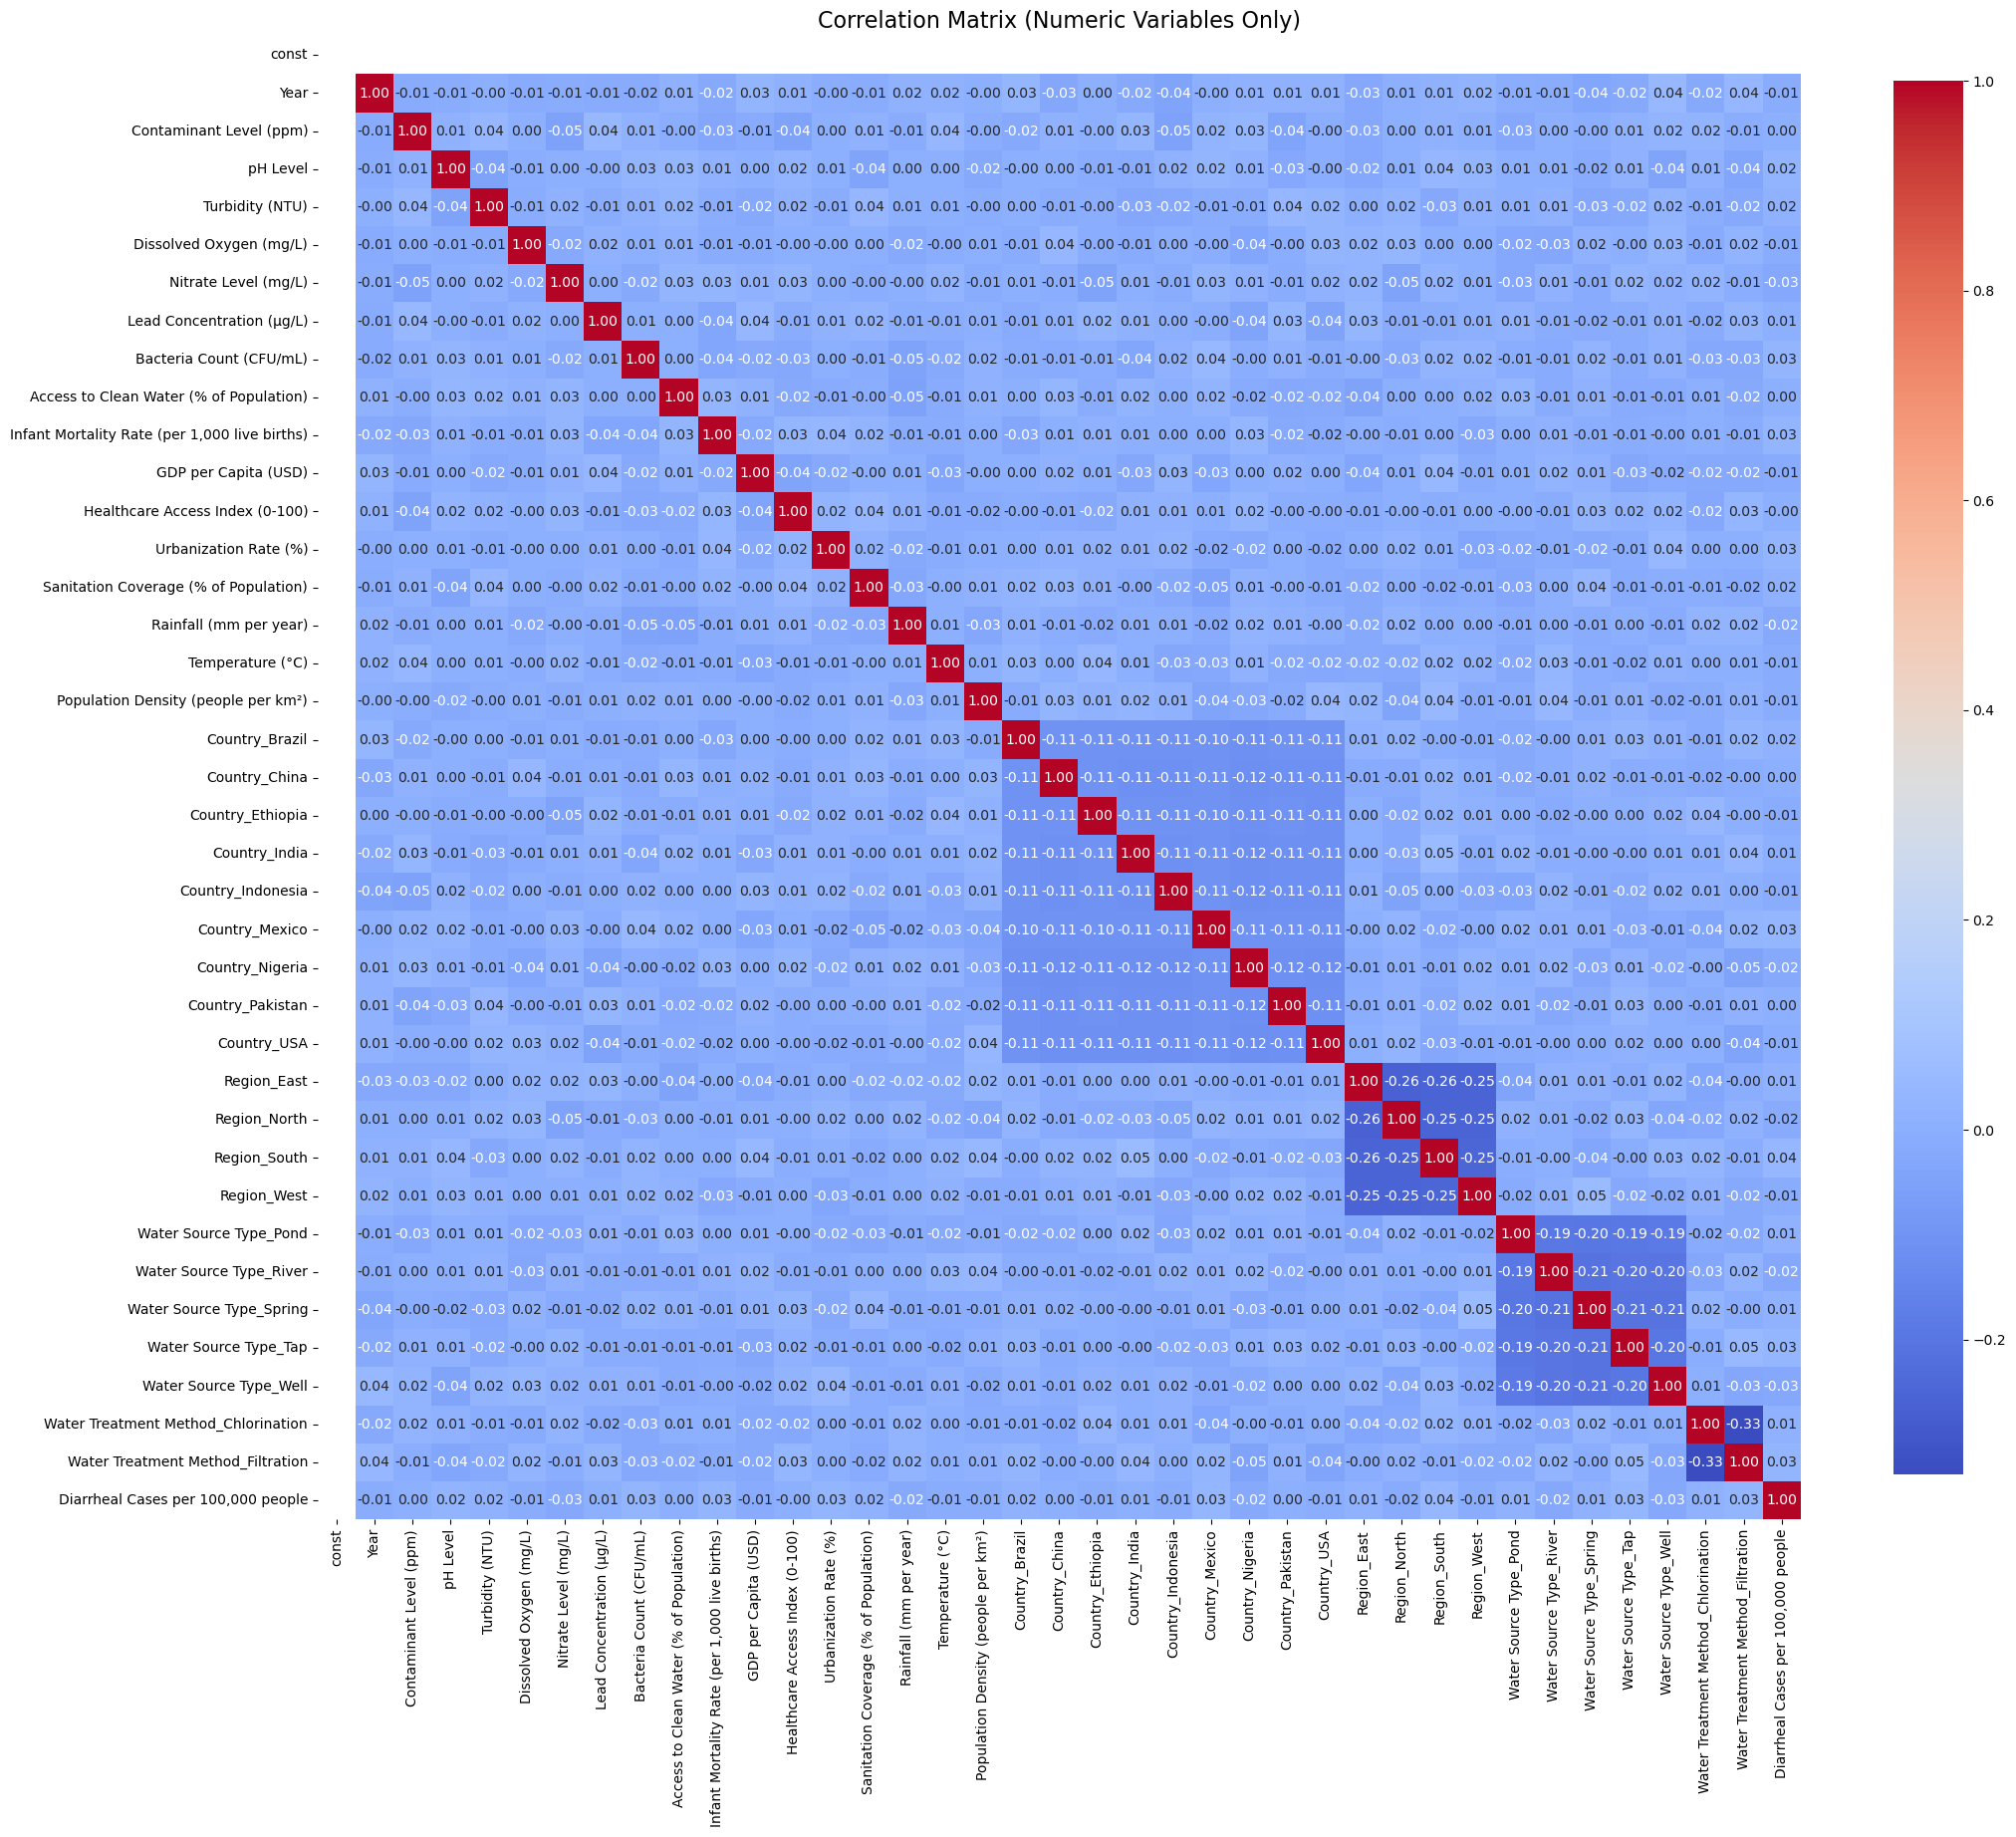

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22, 20))
sns.heatmap(Train.select_dtypes(include='number').corr(), 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            square=True,
            cbar_kws={"shrink": .8})

plt.title("Correlation Matrix (Numeric Variables Only)", fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
lr_model = sm.OLS(y_train, X_train)
results_lr = lr_model.fit()
summarize(results_lr)

,coef,std err,t,P>|t|
const,418.493600,848.428,0.493,0.622
Year,-0.115100,0.421,-0.274,0.784
Contaminant Level (ppm),-0.112400,1.072,-0.105,0.917
pH Level,4.382800,4.255,1.030,0.303
Turbidity (NTU),1.996100,2.153,0.927,0.354
Dissolved Oxygen (mg/L),-0.803700,1.505,-0.534,0.593
Nitrate Level (mg/L),-0.312100,0.212,-1.473,0.141
Lead Concentration (µg/L),0.173000,0.529,0.327,0.744
Bacteria Count (CFU/mL),0.002400,0.002,1.111,0.267
Access to Clean Water (% of Population),0.009400,0.150,0.062,0.950


### R^2 on Train

In [12]:
# R^2
print('R^2 on Train:', results_lr.rsquared)

R^2 on Train: 0.013450659783213692


### Filtering variables by highest t-values and lowest p-values

In [13]:
t_p_values = pd.DataFrame({
    'train_t_val' : results_lr.tvalues,
    'train_p_val' : results_lr.pvalues
})

In [14]:
results_by_t = t_p_values.reindex(
    t_p_values["train_t_val"].abs().sort_values(ascending=False).index
)
print(results_by_t)

                                               train_t_val  train_p_val
Region_South                                      2.131554     0.033153
Water Treatment Method_Filtration                 1.577253     0.114880
Country_Mexico                                    1.531296     0.125839
Nitrate Level (mg/L)                             -1.473183     0.140844
Infant Mortality Rate (per 1,000 live births)     1.464820     0.143112
Region_East                                       1.364510     0.172546
Water Source Type_Tap                             1.332355     0.182881
Urbanization Rate (%)                             1.318909     0.187336
Water Treatment Method_Chlorination               1.289855     0.197236
Bacteria Count (CFU/mL)                           1.111302     0.266559
pH Level                                          1.030081     0.303085
Rainfall (mm per year)                           -0.987759     0.323379
Country_Brazil                                    0.962494     0

Variables of importance:

- Region_South                                      2.131554     0.033153 (CATEGORICAL)
- Water Treatment Method_Filtration                 1.577253     0.114880 (CATEGORICAL)
- Country_Mexico                                    1.531296     0.125839 (CATEGORICAL)
- Nitrate Level (mg/L)                             -1.473183     0.140844
- Infant Mortality Rate (per 1,000 live births)     1.464820     0.143112
- Region_East                                       1.364510     0.172546 (CATEGORICAL)
- Water Source Type_Tap                             1.332355     0.182881 (CATEGORICAL)
- Urbanization Rate (%)                             1.318909     0.187336
- Water Treatment Method_Chlorination               1.289855     0.197236 (CATEGORICAL)
- Bacteria Count (CFU/mL)                           1.111302     0.266559
- pH Level                                          1.030081     0.303085

### Calculating MSE

In [15]:
def predict(X, model):
    # the built-in get_prediction tool returns an array, so we need to convert to a dataframe
    predictions_df = pd.DataFrame(model.get_prediction(X).predicted, columns=['y_hat'], index=X.index)
    return predictions_df['y_hat']

def mse(y, y_hat):
    # calculate the residual error for each individual record
    resid = y - y_hat
    # square the residual (hence "squared error")
    sq_resid = resid**2
    # calculate the sum of squared errors
    SSR = sum(sq_resid)
    # divide by the number of records to get the mean squared error
    MSE = SSR / y.shape[0]
    return MSE

In [16]:
predictions_lr_train = predict(X_train, results_lr)
print('mse train:',mse(y_train, predictions_lr_train))
predictions_lr_test = predict(X_test, results_lr)
print('mse test:',mse(y_test, predictions_lr_test))

mse train: 20393.61207623197
mse test: 21251.037334366836


### Plotting Training Set (Nitrate Level vs Diarrhea)

In [17]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

KeyError: 0

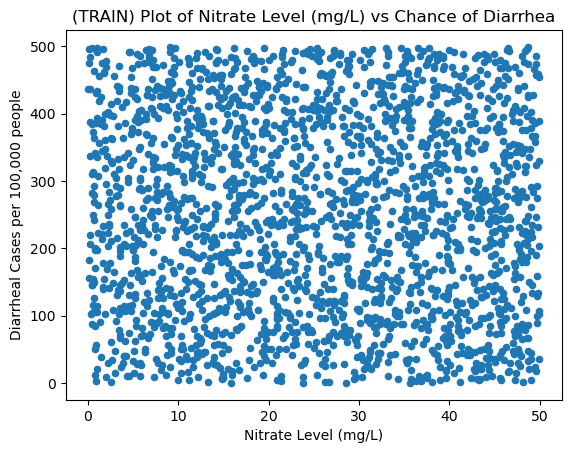

In [18]:
ax = Train.plot.scatter('Nitrate Level (mg/L)', 'Diarrheal Cases per 100,000 people')
ax.set_title("(TRAIN) Plot of Nitrate Level (mg/L) vs Chance of Diarrhea")
abline(ax,
       results_lr.params[0],
       results_lr.params[1],
       'r--',
       linewidth=3)

### Plotting Test Set (Nitrate Level vs. Diarrhea)

KeyError: 0

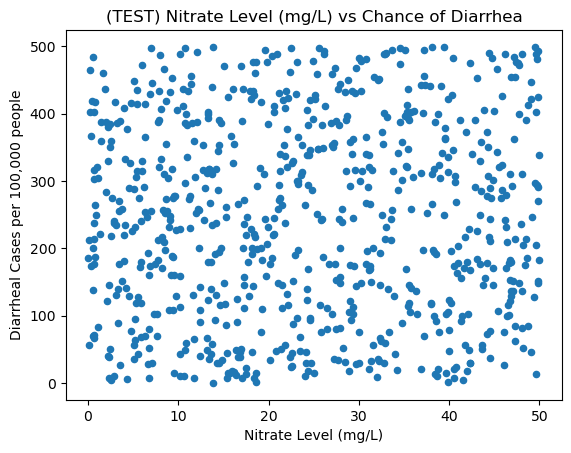

In [19]:
ax = Test.plot.scatter('Nitrate Level (mg/L)', 'Diarrheal Cases per 100,000 people')
ax.set_title("(TEST) Nitrate Level (mg/L) vs Chance of Diarrhea")
abline(ax,
       results_lr.params[0],
       results_lr.params[1],
       'r--',
       linewidth=3)

### Residual Graph

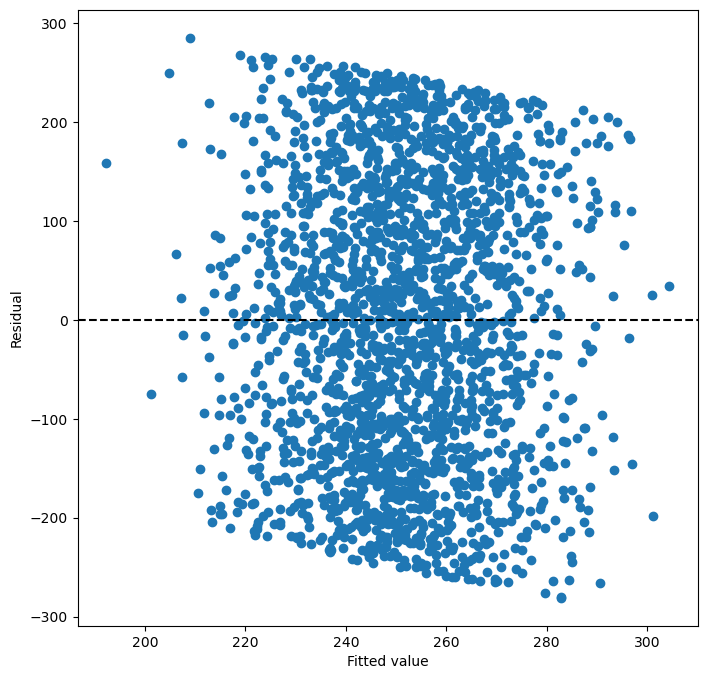

In [21]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(predictions_lr_train, y_train - predictions_lr_train)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')